In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


In [4]:
df = pd.read_csv("online.csv")
df.head()

,Unnamed: 0,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications,Unnamed: 13,9,#@%
0,0,Yes,25001 to 50000,13.0262,Married,Male,Employee,5.0,Positive,560045,28.0,77.6200,Post Graduate,Yes,NaN,swiggyscount
1,1,Yes,No Income,12.9770,Single,Male,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate,Yes,NaN,*7435
2,2,Yes,No Income,12.9770,Single,Female,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate,Yes,NaN,*7435
3,3,Yes,No Income,13.0019,Single,Female,Student,NaN,Positive,560003,NaN,77.5713,Post Graduate,Yes,NaN,*7435
4,4,Yes,More than 50000,13.0626,Married,Male,Self Employeed,NaN,Positive,560015,NaN,77.5284,School,Yes,NaN,*7435


In [5]:
df.shape

(388, 16)

In [6]:
#. check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  388 non-null    int64  
 1   order_status                388 non-null    object 
 2   Monthly Income              388 non-null    object 
 3   latitude                    388 non-null    float64
 4   Marital Status              388 non-null    object 
 5   Gender                      388 non-null    object 
 6   employment_status           388 non-null    object 
 7   Family size                 369 non-null    float64
 8   Reviews                     388 non-null    object 
 9   Pin code                    388 non-null    int64  
 10  Age                         369 non-null    float64
 11  longitude                   388 non-null    float64
 12  Educational Qualifications  388 non-null    object 
 13  Unnamed: 13                 388 non

In [7]:
# checking for missing values
df.isnull().sum()

Unnamed: 0                      0
order_status                    0
Monthly Income                  0
latitude                        0
Marital Status                  0
Gender                          0
employment_status               0
Family size                    19
Reviews                         0
Pin code                        0
Age                            19
longitude                       0
Educational Qualifications      0
Unnamed: 13                     0
9                             388
#@%                           382
dtype: int64

In [8]:
df.columns


Index(['Unnamed: 0', 'order_status', 'Monthly Income', 'latitude',
       'Marital Status', 'Gender', 'employment_status', 'Family size',
       'Reviews', 'Pin code', 'Age', 'longitude', 'Educational Qualifications',
       'Unnamed: 13', '9', '#@%'],
      dtype='object')

In [9]:
df.drop(columns=["Unnamed: 13", "Unnamed: 0", "9", "#@%"], inplace=True)

In [10]:
df.head()

,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications
0,Yes,25001 to 50000,13.0262,Married,Male,Employee,5.0,Positive,560045,28.0,77.6200,Post Graduate
1,Yes,No Income,12.9770,Single,Male,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate
2,Yes,No Income,12.9770,Single,Female,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate
3,Yes,No Income,13.0019,Single,Female,Student,NaN,Positive,560003,NaN,77.5713,Post Graduate
4,Yes,More than 50000,13.0626,Married,Male,Self Employeed,NaN,Positive,560015,NaN,77.5284,School


In [11]:
df.shape

(388, 12)

<Axes: ylabel='Age'>

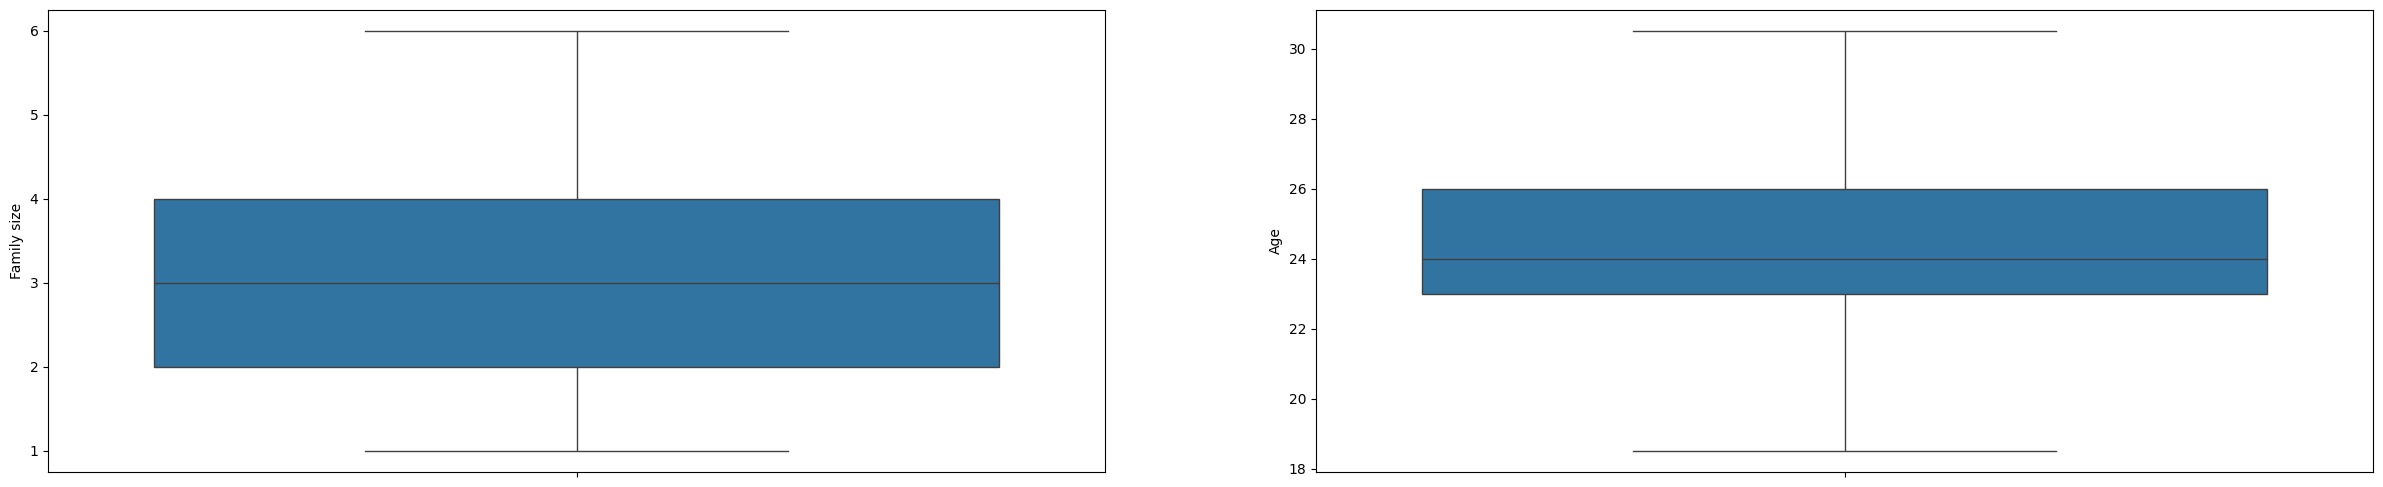

In [34]:
plt.figure(figsize=(30,6))
plt.subplot(1,2,1)
sns.boxplot(df['Family size'])
plt.subplot(1,2,2)
sns.boxplot(df['Age'])

In [13]:
# filling missing values
family_size_mean_value = int(df['Family size'].mean())

In [14]:
df['Family size'] = df['Family size'].fillna(family_size_mean_value)

In [15]:
age_median_value = df['Age'].median()
age_median_value

np.float64(24.0)

In [16]:
df['Age'] = df['Age'].fillna(age_median_value)

In [17]:
df.isnull().sum()

order_status                  0
Monthly Income                0
latitude                      0
Marital Status                0
Gender                        0
employment_status             0
Family size                   0
Reviews                       0
Pin code                      0
Age                           0
longitude                     0
Educational Qualifications    0
dtype: int64

In [18]:
df['Age'].describe()

count    388.000000
mean      24.634021
std        2.897932
min       18.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       33.000000
Name: Age, dtype: float64

In [21]:
q1 = df.describe()['Age']['25%']
q3 = df.describe()['Age']['75%']
IQR = q3 - q1 
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print(q1, q3, IQR, lower_limit, upper_limit)

23.0 26.0 3.0 18.5 30.5


In [ ]:
# Anything below 18.5 and anything above 30.5 is an outlier 
outliers = df[(df['Age'] < lower_limit) | (df['Age'] > upper_limit)]

,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications
16,Yes,25001 to 50000,12.9706,Married,Male,Employee,3.0,Positive,560075,32.0,77.6529,Graduate
26,Yes,10001 to 25000,12.9820,Married,Male,Self Employeed,3.0,Negative,560008,32.0,77.6256,School
31,No,More than 50000,13.0019,Married,Female,Employee,1.0,Positive,560003,32.0,77.5713,Graduate
33,No,No Income,13.0140,Married,Female,House wife,3.0,Positive,560012,32.0,77.5658,Uneducated
71,Yes,25001 to 50000,12.9706,Married,Male,Employee,3.0,Positive,560075,32.0,77.6529,Graduate
74,Yes,More than 50000,12.9037,Married,Male,Employee,5.0,Positive,560061,32.0,77.5376,Graduate
98,Yes,More than 50000,12.9369,Married,Male,Employee,6.0,Positive,560095,32.0,77.6407,Post Graduate
105,Yes,More than 50000,13.0487,Married,Male,Self Employeed,6.0,Positive,560024,31.0,77.5923,School
139,Yes,No Income,12.9889,Married,Female,House wife,5.0,Positive,560020,32.0,77.5741,School
147,Yes,No Income,12.9635,Single,Male,Student,5.0,Positive,560002,18.0,77.5821,Graduate


In [26]:
non_outliers = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

In [27]:
non_outliers

,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications
0,Yes,25001 to 50000,13.0262,Married,Male,Employee,5.0,Positive,560045,28.0,77.6200,Post Graduate
1,Yes,No Income,12.9770,Single,Male,Student,3.0,Positive,560009,24.0,77.5773,Post Graduate
2,Yes,No Income,12.9770,Single,Female,Student,3.0,Positive,560009,24.0,77.5773,Post Graduate
3,Yes,No Income,13.0019,Single,Female,Student,3.0,Positive,560003,24.0,77.5713,Post Graduate
4,Yes,More than 50000,13.0626,Married,Male,Self Employeed,3.0,Positive,560015,24.0,77.5284,School
...,...,...,...,...,...,...,...,...,...,...,...,...
383,Yes,No Income,12.9883,Single,Female,Student,5.0,Positive,560051,24.0,77.5987,Post Graduate
384,Yes,No Income,13.0223,Single,Male,Student,3.0,Positive,560049,23.0,77.7132,Graduate
385,Yes,10001 to 25000,12.9850,Single,Female,Student,5.0,Positive,560010,22.0,77.5533,Post Graduate
386,Yes,10001 to 25000,12.9698,Single,Female,Employee,3.0,Positive,560066,22.0,77.7500,Graduate


In [33]:
# Trimming technique = delete all outliers
# Capping technique
df['Age'] = df['Age'].clip(lower_limit,upper_limit)